In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('in-vehicle-coupon-recommendation.csv')
print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (12684, 26)
       destination  passanger weather  temperature  time  \
0  No Urgent Place      Alone   Sunny           55   2PM   
1  No Urgent Place  Friend(s)   Sunny           80  10AM   
2  No Urgent Place  Friend(s)   Sunny           80  10AM   
3  No Urgent Place  Friend(s)   Sunny           80   2PM   
4  No Urgent Place  Friend(s)   Sunny           80   2PM   

                  coupon expiration  gender age      maritalStatus  ...  \
0        Restaurant(<20)         1d  Female  21  Unmarried partner  ...   
1           Coffee House         2h  Female  21  Unmarried partner  ...   
2  Carry out & Take away         2h  Female  21  Unmarried partner  ...   
3           Coffee House         2h  Female  21  Unmarried partner  ...   
4           Coffee House         1d  Female  21  Unmarried partner  ...   

   CoffeeHouse CarryAway RestaurantLessThan20 Restaurant20To50  \
0        never       NaN                  4~8              1~3   
1        never       NaN     

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

In [5]:
print("Missing Values:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

Missing Values:
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
dtype: int64


In [6]:
# Summary of categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols[:]: 
    print(f"\n{col}:")
    print(df[col].value_counts().head())


destination:
destination
No Urgent Place    6283
Home               3237
Work               3164
Name: count, dtype: int64

passanger:
passanger
Alone        7305
Friend(s)    3298
Partner      1075
Kid(s)       1006
Name: count, dtype: int64

weather:
weather
Sunny    10069
Snowy     1405
Rainy     1210
Name: count, dtype: int64

time:
time
6PM     3230
7AM     3164
10AM    2275
2PM     2009
10PM    2006
Name: count, dtype: int64

coupon:
coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: count, dtype: int64

expiration:
expiration
1d    7091
2h    5593
Name: count, dtype: int64

gender:
gender
Female    6511
Male      6173
Name: count, dtype: int64

age:
age
21        2653
26        2559
31        2039
50plus    1788
36        1319
Name: count, dtype: int64

maritalStatus:
maritalStatus
Married partner      5100
Single               4752
Unmarried partner    2186
Divorced 

C:\Users\swaru\AppData\Local\Temp\ipykernel_24528\124936217.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [7]:
df = df.drop(columns=['car'])

freq_cols = ["Bar", "CoffeeHouse", "CarryAway",
                 "RestaurantLessThan20", "Restaurant20To50"]
for col in freq_cols:
    df[col] = df[col].fillna("never")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  Bar                   12684 non-null  str  
 15  CoffeeHouse           12684 non-null  str  
 16  CarryAway      

In [8]:
df = df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
Index: 12610 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12610 non-null  str  
 1   passanger             12610 non-null  str  
 2   weather               12610 non-null  str  
 3   temperature           12610 non-null  int64
 4   time                  12610 non-null  str  
 5   coupon                12610 non-null  str  
 6   expiration            12610 non-null  str  
 7   gender                12610 non-null  str  
 8   age                   12610 non-null  str  
 9   maritalStatus         12610 non-null  str  
 10  has_children          12610 non-null  int64
 11  education             12610 non-null  str  
 12  occupation            12610 non-null  str  
 13  income                12610 non-null  str  
 14  Bar                   12610 non-null  str  
 15  CoffeeHouse           12610 non-null  str  
 16  CarryAway           

##### 74 Data points where duplicate

In [9]:
df['expiration'].unique()

<ArrowStringArray>
['1d', '2h']
Length: 2, dtype: str

In [10]:
df['age'].unique()

<ArrowStringArray>
['21', '46', '26', '31', '41', '50plus', '36', 'below21']
Length: 8, dtype: str

In [11]:
df['income'].unique()

<ArrowStringArray>
[ '$37500 - $49999',  '$62500 - $74999',  '$12500 - $24999',
  '$75000 - $87499',  '$50000 - $62499',  '$25000 - $37499',
  '$100000 or More',  '$87500 - $99999', 'Less than $12500']
Length: 9, dtype: str

In [12]:
df['Bar'].unique()

<ArrowStringArray>
['never', 'less1', '1~3', 'gt8', '4~8']
Length: 5, dtype: str

In [13]:
print("CoffeeHouse unique values:", df['CoffeeHouse'].unique())
print("CarryAway unique values:", df['CarryAway'].unique())
print("RestaurantLessThan20 unique values:", df['RestaurantLessThan20'].unique())
print("Restaurant20To50 unique values:", df['Restaurant20To50'].unique())

CoffeeHouse unique values: <ArrowStringArray>
['never', 'less1', '4~8', '1~3', 'gt8']
Length: 5, dtype: str
CarryAway unique values: <ArrowStringArray>
['never', '4~8', '1~3', 'gt8', 'less1']
Length: 5, dtype: str
RestaurantLessThan20 unique values: <ArrowStringArray>
['4~8', '1~3', 'less1', 'gt8', 'never']
Length: 5, dtype: str
Restaurant20To50 unique values: <ArrowStringArray>
['1~3', 'less1', 'never', 'gt8', '4~8']
Length: 5, dtype: str


Distribution by time and coupon:
coupon  Bar  Carry out & Take away  Coffee House  Restaurant(20-50)  \
time                                                                  
10AM    443                    515           898                112   
10PM    399                    459           297                380   
2PM     118                    218           793                181   
6PM     563                    433          1088                388   
7AM     487                    719           913                427   

coupon  Restaurant(<20)  
time                     
10AM                303  
10PM                464  
2PM                 696  
6PM                 748  
7AM                 568  

Distribution by expiration, time, and coupon:
coupon           Bar  Carry out & Take away  Coffee House  Restaurant(20-50)  \
expiration time                                                                
1d         10AM  377                    148           336                 70   


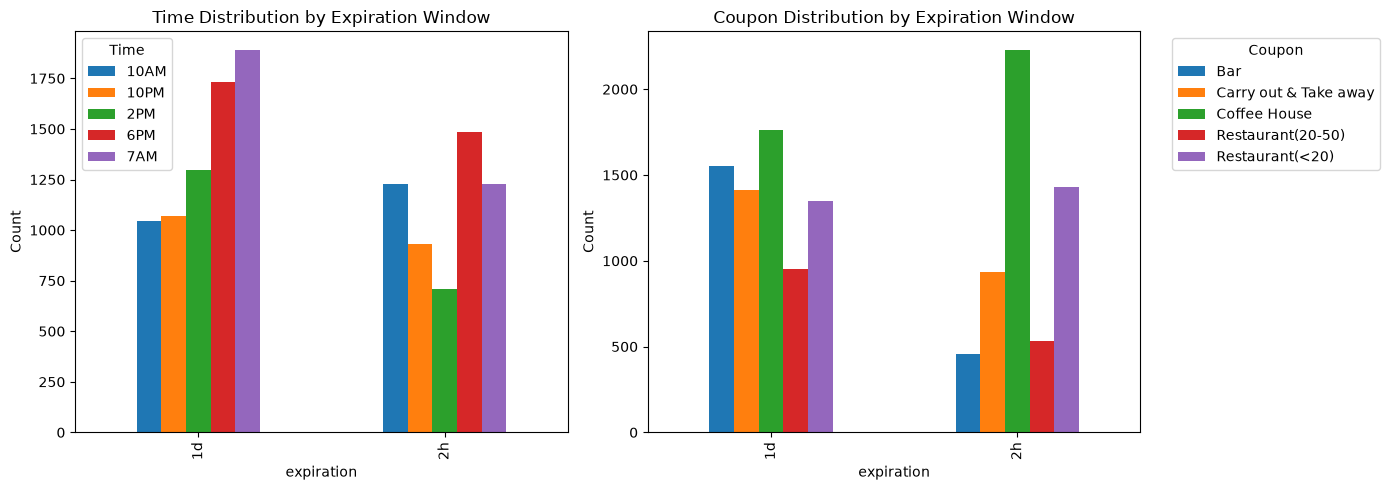

In [14]:
# Distribution of 2 hour window vs 1d window across time and coupon
window_coupon_dist = df.groupby(['time', 'coupon']).size().unstack(fill_value=0)
print("Distribution by time and coupon:")
print(window_coupon_dist)

# More detailed view with expiration windows
expiration_dist = df.groupby(['expiration', 'time', 'coupon']).size().unstack(fill_value=0)
print("\nDistribution by expiration, time, and coupon:")
print(expiration_dist)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby(['expiration', 'time']).size().unstack().plot(kind='bar', ax=axes[0])
axes[0].set_title('Time Distribution by Expiration Window')
axes[0].set_ylabel('Count')
axes[0].legend(title='Time')

df.groupby(['expiration', 'coupon']).size().unstack().plot(kind='bar', ax=axes[1])
axes[1].set_title('Coupon Distribution by Expiration Window')
axes[1].set_ylabel('Count')
axes[1].legend(title='Coupon', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()